<a href="https://colab.research.google.com/github/braim/nids-tta/blob/main/colab/1-ae/NIDS_1_0_0_AE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIDS 1.0.0 Simple AutoEncoder
This notebook implements a reusable anomaly detection pipeline using an Autoencoder

In [1]:
# Simple AutoEncoder
# Install necessary libraries and import
try:
    import polars
    import kagglehub
except ImportError:
    !pip install polars kagglehub

import kagglehub
import os
import polars as pl
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix, classification_report
import gc
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import random

In [2]:


@dataclass
class Hyperparameters:
    # ── Reproducibility ───────────────────────────────────────────────────────────
    seed: int = 42
    """Hyperparameters for the AutoEncoder pipeline."""
    batch_size: int = 256
    learning_rate: float = 0.001
    num_epochs: int = 10
    test_size: float = 0.2
    random_state: int = 42

    # Network dimensions
    hidden_dim1: int = 32
    hidden_dim2: int = 16

# Initialize config
config = Hyperparameters()
print(f"Hyperparameters: {config}")


# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)
np.random.seed(config.seed)
random.seed(config.seed)
torch.backends.cudnn.deterministic = True

Hyperparameters: Hyperparameters(seed=42, batch_size=256, learning_rate=0.001, num_epochs=10, test_size=0.2, random_state=42, hidden_dim1=32, hidden_dim2=16)



--- Starting pipeline for dataset: seyhed/nf-unsw-nb15-v3 ---
Using Colab cache for faster access to the 'nf-unsw-nb15-v3' dataset.
Dataset downloaded to: /kaggle/input/nf-unsw-nb15-v3
Loading data from: /kaggle/input/nf-unsw-nb15-v3/NF-UNSW-NB15-v3.csv
Data loaded. Shape: (2365424, 55)
Using device: cpu
Training Autoencoder...
Epoch [2/10], Loss: 0.026937
Epoch [4/10], Loss: 0.018546
Epoch [6/10], Loss: 0.012551
Epoch [8/10], Loss: 0.011812
Epoch [10/10], Loss: 0.010936
Evaluating...
AUC: 0.9989, F1-Score: 0.9531


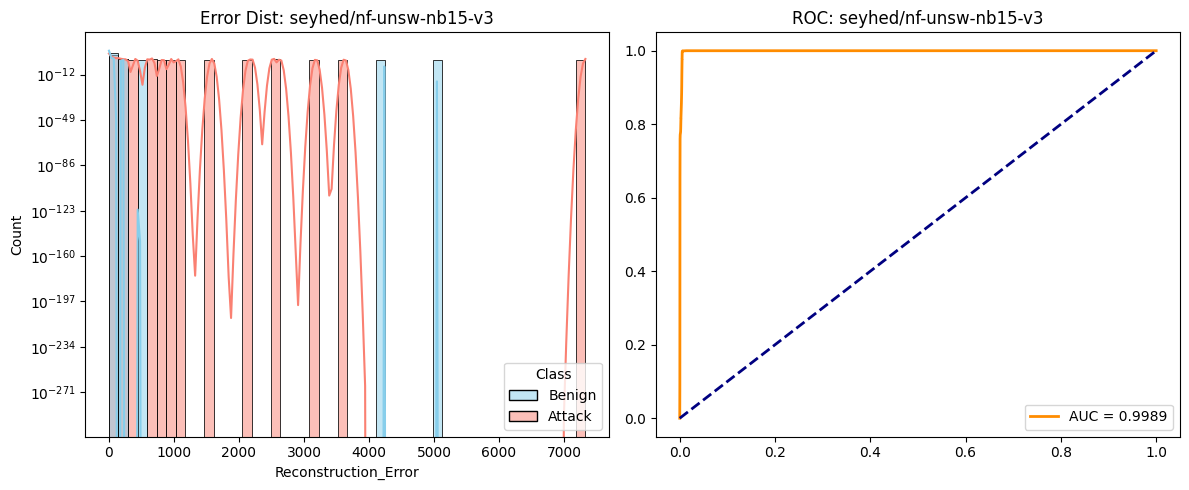


--- Starting pipeline for dataset: seyhed/nf-ton-iot-v3 ---
Using Colab cache for faster access to the 'nf-ton-iot-v3' dataset.
Dataset downloaded to: /kaggle/input/nf-ton-iot-v3
Loading data from: /kaggle/input/nf-ton-iot-v3/NF-ToN-IoT-v3.csv
Data loaded. Shape: (27520260, 55)
Using device: cpu
Training Autoencoder...
Epoch [2/10], Loss: 0.171879
Epoch [4/10], Loss: 0.151403
Epoch [6/10], Loss: 0.126299
Epoch [8/10], Loss: 0.119374
Epoch [10/10], Loss: 0.122491
Evaluating...
AUC: 0.8602, F1-Score: 0.8171


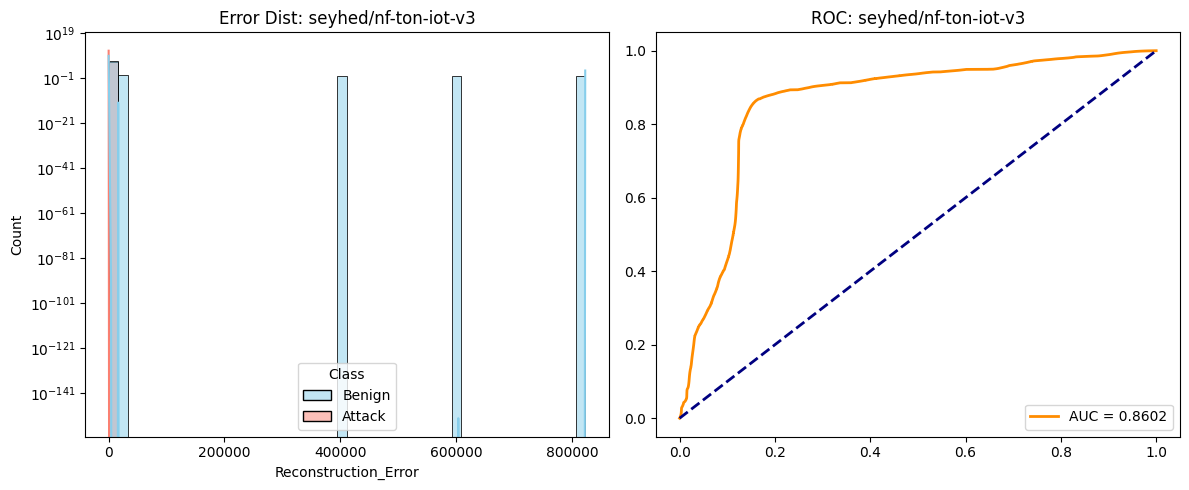


--- Starting pipeline for dataset: seyhed/nf-cicids2018-v3 ---
Using Colab cache for faster access to the 'nf-cicids2018-v3' dataset.
Dataset downloaded to: /kaggle/input/nf-cicids2018-v3
Loading data from: /kaggle/input/nf-cicids2018-v3/NF-CICIDS2018-v3.csv
Data loaded. Shape: (20115529, 55)
Using device: cpu
Training Autoencoder...
Epoch [2/10], Loss: 0.032158
Epoch [4/10], Loss: 0.023138
Epoch [6/10], Loss: 0.018724
Epoch [8/10], Loss: 0.017200
Epoch [10/10], Loss: 0.014174
Evaluating...
AUC: 0.8464, F1-Score: 0.4876


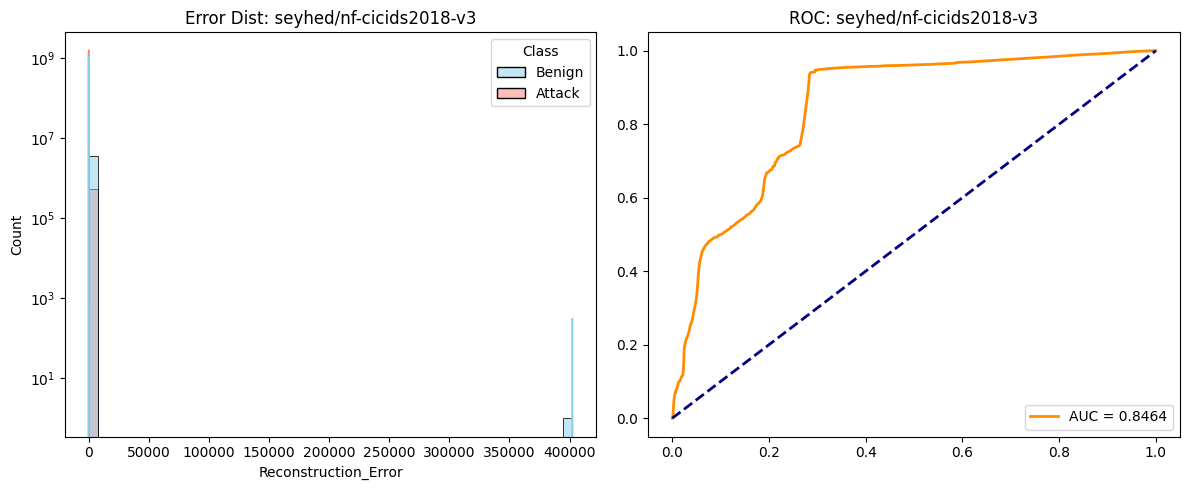


--- Starting pipeline for dataset: seyhed/nf-bot-iot-v3 ---
Using Colab cache for faster access to the 'nf-bot-iot-v3' dataset.
Dataset downloaded to: /kaggle/input/nf-bot-iot-v3
Loading data from: /kaggle/input/nf-bot-iot-v3/NF-BoT-IoT-v3.csv
Data loaded. Shape: (16933808, 55)
Using device: cpu
Training Autoencoder...
Epoch [2/10], Loss: 8.560297
Epoch [4/10], Loss: 2.320227
Epoch [6/10], Loss: 1.353038
Epoch [8/10], Loss: 0.832094
Epoch [10/10], Loss: 0.712834
Evaluating...
AUC: 0.6904, F1-Score: 0.9937


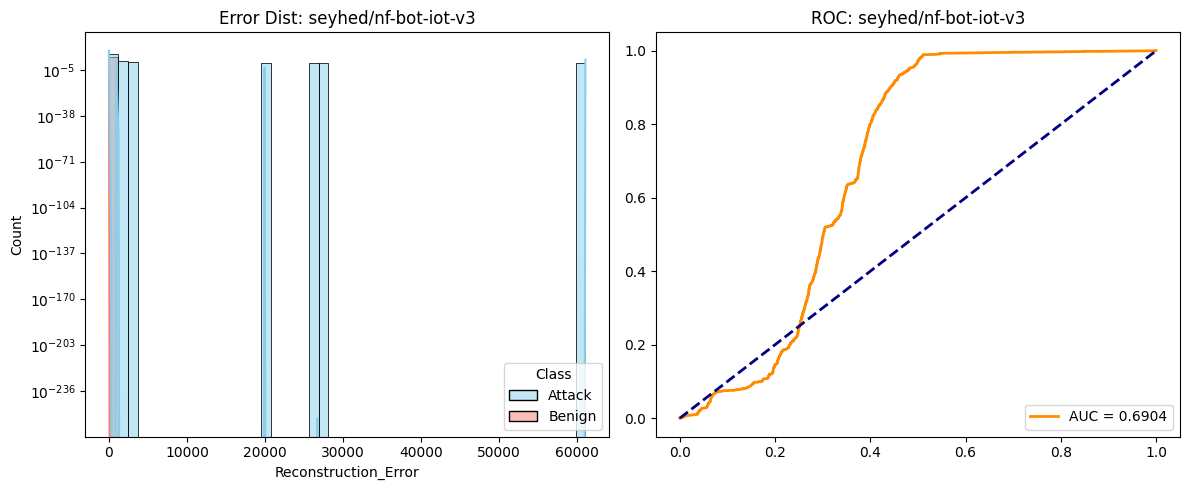


--- Performance Summary ---
                   Dataset       AUC  Optimal Threshold  F1-Score
0   seyhed/nf-unsw-nb15-v3  0.998876           0.060528  0.953090
1     seyhed/nf-ton-iot-v3  0.860175           0.006316  0.817088
2  seyhed/nf-cicids2018-v3  0.846438           0.003283  0.487630
3     seyhed/nf-bot-iot-v3  0.690428           0.091612  0.993694


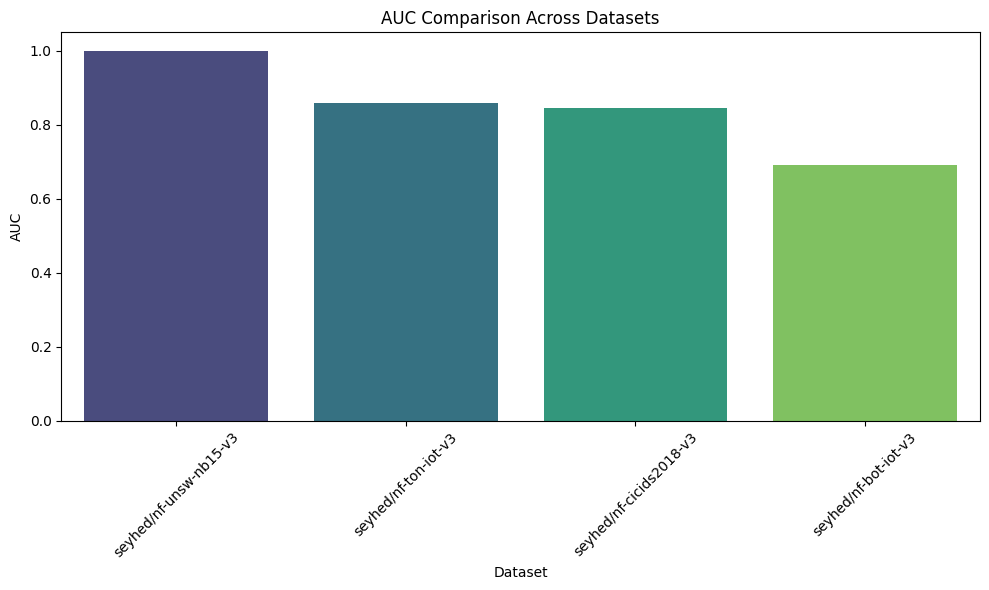

In [3]:
# ==========================================
# MODEL DEFINITION: Autoencoder (AE)
# ==========================================

class Autoencoder(nn.Module):
    def __init__(self, input_dim, config):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, config.hidden_dim1),
            nn.ReLU(),
            nn.Linear(config.hidden_dim1, config.hidden_dim2),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(config.hidden_dim2, config.hidden_dim1),
            nn.ReLU(),
            nn.Linear(config.hidden_dim1, input_dim)
            # No activation for output layer as data is StandardScaled
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

def load_dataset(dataset_name: str):
    """Downloads and loads the dataset using Polars."""
    try:
        download_path = kagglehub.dataset_download(dataset_name)
        print(f"Dataset downloaded to: {download_path}")

        # Find CSV file
        csv_files = []
        for root, dirs, files in os.walk(download_path):
            for file in files:
                if file.endswith('.csv'):
                    csv_files.append(os.path.join(root, file))

        if not csv_files:
            print("No CSV file found.")
            return None

        csv_path = csv_files[0]
        print(f"Loading data from: {csv_path}")

        # Use Polars to read the CSV
        df = pl.read_csv(csv_path, infer_schema_length=10000)
        print(f"Data loaded. Shape: {df.shape}")

        # --- Preprocessing ---
        # Drop 'Attack' column if present
        if "Attack" in df.columns:
            df = df.drop("Attack")

        # Encode IP addresses
        for col in ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR']:
            if col in df.columns:
                df = df.with_columns(pl.col(col).cast(pl.Categorical).to_physical())

        # Separate Target and Features
        if "Label" not in df.columns:
            print("'Label' column missing.")
            return None

        return df

    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# 4. Define the pipeline function
def run_pipeline(dataset_name, config):
    """
    Downloads, preprocesses, trains, and evaluates an anomaly detection model using Polars for efficiency.
    """
    print(f"\n--- Starting pipeline for dataset: {dataset_name} ---")

    # --- Download and Load Data ---
    df = load_dataset(dataset_name)
    if df is None:
        return None

    y = df["Label"].to_numpy()
    X_df = df.drop("Label")

    # Convert to numpy float32
    X = X_df.to_numpy().astype(np.float32)

    # Cleanup Polars objects to free memory
    del df, X_df
    gc.collect()

    # Handle Inf/NaN
    if np.isinf(X).any():
        X[np.isinf(X)] = np.nan
    if np.isnan(X).any():
        col_mean = np.nanmean(X, axis=0)
        inds = np.where(np.isnan(X))
        X[inds] = np.take(col_mean, inds[1])

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=config.test_size, random_state=config.random_state)

    # Filter Benign for Training
    X_train_benign = X_train[y_train == 0]

    # Convert to Tensors
    train_tensor = torch.FloatTensor(X_train_benign)
    test_tensor = torch.FloatTensor(X_test)
    test_labels = torch.LongTensor(y_test)

    # Cleanup numpy arrays
    del X, y, X_train, X_train_benign, X_test, y_train, y_test
    gc.collect()

    # DataLoaders
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=config.batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(test_tensor, test_labels), batch_size=config.batch_size, shuffle=False)

    # --- Training ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    input_dim = train_tensor.shape[1]
    model = Autoencoder(input_dim, config).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    criterion = nn.MSELoss()

    print("Training Autoencoder...")
    model.train()

    for epoch in range(config.num_epochs):
        running_loss = 0.0
        for batch in train_loader:
            features = batch[0].to(device)
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, features)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * features.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        if (epoch + 1) % 2 == 0:
            print(f'Epoch [{epoch+1}/{config.num_epochs}], Loss: {epoch_loss:.6f}')

    # --- Evaluation ---
    print("Evaluating...")
    model.eval()
    reconstruction_errors = []
    true_labels = []

    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            outputs = model(features)
            loss = torch.mean((features - outputs)**2, dim=1)
            reconstruction_errors.extend(loss.cpu().numpy())
            true_labels.extend(labels.numpy())

    reconstruction_errors = np.array(reconstruction_errors)
    true_labels = np.array(true_labels)

    # Metrics
    fpr, tpr, thresholds = roc_curve(true_labels, reconstruction_errors)
    roc_auc = auc(fpr, tpr)

    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    y_pred = (reconstruction_errors > optimal_threshold).astype(int)
    f1 = f1_score(true_labels, y_pred)

    print(f"AUC: {roc_auc:.4f}, F1-Score: {f1:.4f}")

    # Cleanup PyTorch objects
    del model, optimizer, criterion, train_tensor, test_tensor, train_loader, test_loader
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return {
        'dataset_name': dataset_name,
        'auc': roc_auc,
        'optimal_threshold': optimal_threshold,
        'f1_score': f1,
        'fpr': fpr,
        'tpr': tpr,
        'reconstruction_errors': reconstruction_errors,
        'true_labels': true_labels
    }

# 5. Main Execution Loop
datasets = [
    'seyhed/nf-unsw-nb15-v3',
    'seyhed/nf-ton-iot-v3',
    'seyhed/nf-cicids2018-v3',
    'seyhed/nf-bot-iot-v3'  # Included as requested
]

results_list = []

for dataset_name in datasets:
    result = run_pipeline(dataset_name, config)

    if result:
        # --- Visualization per dataset ---
        viz_df = pd.DataFrame({
            'Reconstruction_Error': result['reconstruction_errors'],
            'Label': result['true_labels']
        })
        viz_df['Class'] = viz_df['Label'].map({0: 'Benign', 1: 'Attack'})

        plt.figure(figsize=(12, 5))

        # Error Distribution
        plt.subplot(1, 2, 1)
        sns.histplot(data=viz_df, x='Reconstruction_Error', hue='Class', kde=True, bins=50, palette=['skyblue', 'salmon'])
        plt.title(f'Error Dist: {dataset_name}')
        plt.yscale('log')

        # ROC Curve
        plt.subplot(1, 2, 2)
        plt.plot(result['fpr'], result['tpr'], color='darkorange', lw=2, label=f'AUC = {result["auc"]:.4f}')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title(f'ROC: {dataset_name}')
        plt.legend(loc="lower right")

        plt.tight_layout()
        plt.show()

        # Save summary stats
        results_list.append({
            'Dataset': dataset_name,
            'AUC': result['auc'],
            'Optimal Threshold': result['optimal_threshold'],
            'F1-Score': result['f1_score']
        })

        # Explicit cleanup of large result data
        del result, viz_df
        gc.collect()

# 6. Final Summary
if results_list:
    summary_df = pd.DataFrame(results_list)
    print("\n--- Performance Summary ---")
    print(summary_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x='Dataset', y='AUC', hue='Dataset', palette='viridis', legend=False)
    plt.title('AUC Comparison Across Datasets')
    plt.xticks(rotation=45)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


## Compare and Visualize Results

### Subtask:
Aggregate the performance metrics from the executed pipelines into a summary DataFrame and visualize the AUC scores.


**Reasoning**:
I will create a summary DataFrame from the `results_list` containing performance metrics for each dataset. Then, I will display this DataFrame and generate a bar chart to compare the AUC scores across the datasets.



Performance Summary:
                   Dataset       AUC  Optimal Threshold  F1-Score
0   seyhed/nf-unsw-nb15-v3  0.998876           0.060528  0.953090
1     seyhed/nf-ton-iot-v3  0.860175           0.006316  0.817088
2  seyhed/nf-cicids2018-v3  0.846438           0.003283  0.487630
3     seyhed/nf-bot-iot-v3  0.690428           0.091612  0.993694


/tmp/ipykernel_110721/2126340007.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Dataset', y='AUC', palette='viridis')


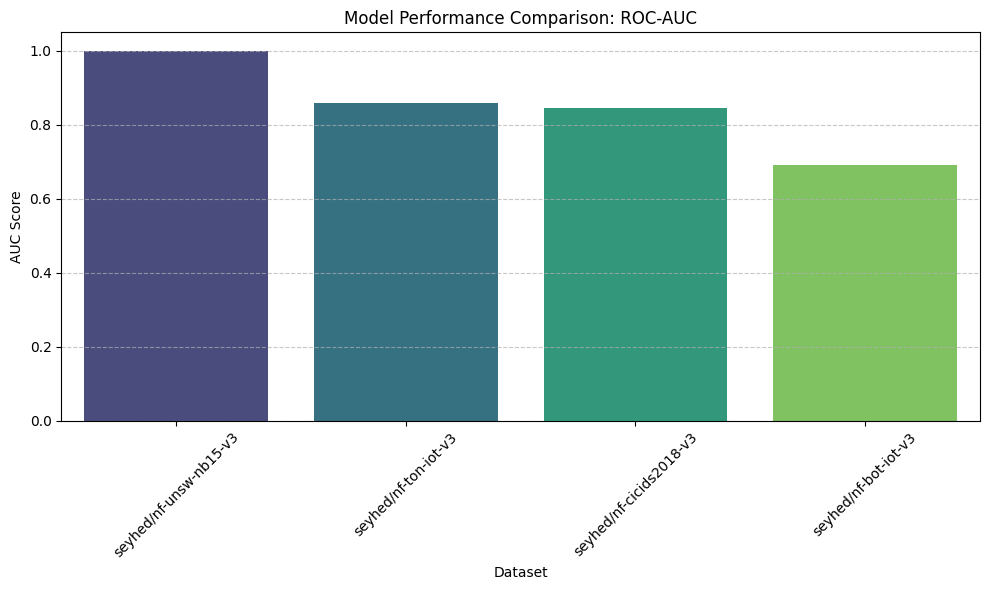

In [12]:
# Create a summary DataFrame from the results list
summary_data = []
for res in results_list:
    summary_data.append({
        'Dataset': res['Dataset'],
        'AUC': res['AUC'],
        'Optimal Threshold': res['Optimal Threshold'],
        'F1-Score': res['F1-Score']
    })

summary_df = pd.DataFrame(summary_data)

# Display the summary table
print("Performance Summary:")
print(summary_df)

# Visualize AUC Scores if data is available
if not summary_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x='Dataset', y='AUC', palette='viridis')
    plt.title('Model Performance Comparison: ROC-AUC')
    plt.xlabel('Dataset')
    plt.ylabel('AUC Score')
    plt.ylim(0.0, 1.05)  # Set limit slightly above 1 for better visualization
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")